In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pydose_rt as PDRT

from pydose_rt.data import loaders
from pydose_rt.utils.utils import find_patient_paths

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

In [12]:
machine_config = PDRT.MachineConfig(number_of_leaf_pairs=80, tpr_20_10=0.73, mean_photon_energy_MeV=0.39)

patient_dir = '/home/bolo/Documents/PyDoseRT/test_data/Josef_Testing/Data/MrAlderson/'
ct_folder, rtplan_path, rtdose_path, rtstruct_path = find_patient_paths(patient_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.cuda.is_available():
    torch.cuda.device(device)
    torch.randn(1, device=device)  # triggers context creation
    torch.cuda.synchronize()


patient, beam_sequences = loaders.load_dicom(
            ct_folder=ct_folder,
            dose_path=rtdose_path,
            plan_path=rtplan_path,
            struct_path=rtstruct_path,
            # new_spacing=(3, 3, 3),
            struct_names=["PTV", "FemoralHead_L", "FemoralHead_R", "Bladder", "Rectum"],
            use_delivery=True
            )
beam_sequence = beam_sequences[0]
engine = PDRT.DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=patient.resolution,
    dose_grid_shape=patient.density_image.shape,
    kernel_size=75,
    beam_template=beam_sequence,
    device=device,
    dtype=dtype)
engine.calibrate(110, beam_sequence)
patient = patient.to(engine.dtype).to(engine.device)
beam_sequence = beam_sequence.to(engine.device).to(engine.dtype)
dose = engine.compute_dose(beam_sequence, density_image=patient.density_image).detach().cpu().numpy()

/home/bolo/Documents/PyDoseRT/src/pydose_rt/geometry/projections.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


Calibration failed. Adjusting calibration factor to: 0.0024731604597619293


In [13]:
dose.shape

(1, 160, 190, 190)

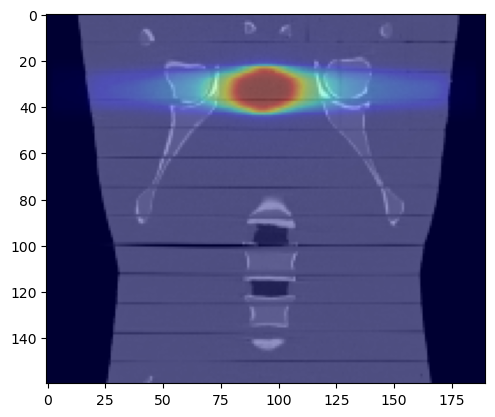

In [35]:
plt.imshow(patient.density_image.cpu().numpy()[:, 100, :], cmap='gray')
plt.imshow(dose[0, :, 100, :], cmap='jet', vmax=dose.max(), alpha=0.4)

(320, 128, 128)


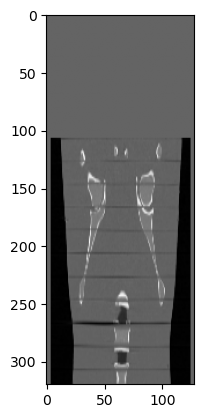

: 

In [ ]:
preprocessed_path = '/home/bolo/Documents/PyDoseRT/test_data/Josef_Testing/large/MrAlderson_test_loc_large_1/'
pre_CT = np.load(preprocessed_path + 'CT.npy')
print(pre_CT.shape)
plt.imshow(pre_CT[:, 64, :], cmap='gray')